In [28]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import (Input, Dense, Reshape, Flatten, Dropout,
                                     BatchNormalization, Conv2D,
                                     Conv2DTranspose, LeakyReLU)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

In [29]:
# -------------------------------
# Load and Preprocess Dataset
# -------------------------------
(X_train, _), (_, _) = mnist.load_data()

In [30]:
X_train = X_train.astype(np.float32)
X_train = (X_train - 127.5) / 127.5
X_train = np.expand_dims(X_train, axis=-1)

In [31]:
img_shape = (28, 28, 1)
latent_dim = 100

In [32]:
# -------------------------------
# Generator
# -------------------------------
def build_generator():

    model = Sequential()

    model.add(Dense(7 * 7 * 128, input_dim=latent_dim))
    model.add(Reshape((7, 7, 128)))

    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Conv2DTranspose(128,
                              kernel_size=4,
                              strides=2,
                              padding='same'))

    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Conv2DTranspose(64,
                              kernel_size=4,
                              strides=2,
                              padding='same'))

    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Conv2D(1,
                     kernel_size=7,
                     activation='tanh',
                     padding='same'))

    noise = Input(shape=(latent_dim,))
    img = model(noise)

    return Model(noise, img)

In [33]:
# -------------------------------
# Discriminator
# -------------------------------
def build_discriminator():

    model = Sequential()

    model.add(Conv2D(64,
                     kernel_size=3,
                     strides=2,
                     padding='same',
                     input_shape=img_shape))

    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.25))

    model.add(Conv2D(128,
                     kernel_size=3,
                     strides=2,
                     padding='same'))

    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.25))

    model.add(Flatten())

    model.add(Dense(1, activation='sigmoid'))

    img = Input(shape=img_shape)
    validity = model(img)

    return Model(img, validity)

In [34]:
# -------------------------------
# Compile Models
# -------------------------------
optimizer = Adam(learning_rate=0.0002, beta_1=0.5)

In [35]:
discriminator = build_discriminator()

In [36]:
discriminator.compile(loss='binary_crossentropy',
                      optimizer=optimizer,
                      metrics=['accuracy'])

In [37]:
generator = build_generator()

In [38]:
z = Input(shape=(latent_dim,))
img = generator(z)

In [39]:
discriminator.trainable = False

In [40]:
validity = discriminator(img)

In [41]:
combined = Model(z, validity)

In [42]:
combined.compile(loss='binary_crossentropy',
                 optimizer=optimizer)

In [43]:
# -------------------------------
# Training Parameters
# -------------------------------
epochs = 40
batch_size = 64

In [44]:
valid = np.ones((batch_size, 1))
fake = np.zeros((batch_size, 1))

In [45]:
# -------------------------------
# Training Loop
# -------------------------------
for epoch in range(epochs):

    idx = np.random.randint(0,
                            X_train.shape[0],
                            batch_size)

    real_imgs = X_train[idx]

    noise = np.random.normal(0,
                             1,
                             (batch_size, latent_dim))

    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs,
                                               valid)

    d_loss_fake = discriminator.train_on_batch(fake_imgs,
                                               fake)

    d_loss = 0.5 * np.add(d_loss_real,
                          d_loss_fake)

    noise = np.random.normal(0,
                             1,
                             (batch_size, latent_dim))

    g_loss = combined.train_on_batch(noise,
                                     valid)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"D Loss: {d_loss[0]:.4f} | "
          f"Accuracy: {100*d_loss[1]:.2f}% | "
          f"G Loss: {g_loss:.4f}")

Epoch 1/40 | D Loss: 0.7172 | Accuracy: 27.34% | G Loss: 0.6956
Epoch 2/40 | D Loss: 0.7143 | Accuracy: 32.03% | G Loss: 0.6795
Epoch 3/40 | D Loss: 0.7160 | Accuracy: 26.28% | G Loss: 0.6672
Epoch 4/40 | D Loss: 0.7142 | Accuracy: 24.58% | G Loss: 0.6593
Epoch 5/40 | D Loss: 0.7131 | Accuracy: 23.57% | G Loss: 0.6490
Epoch 6/40 | D Loss: 0.7133 | Accuracy: 22.05% | G Loss: 0.6414
Epoch 7/40 | D Loss: 0.7134 | Accuracy: 20.17% | G Loss: 0.6342
Epoch 8/40 | D Loss: 0.7137 | Accuracy: 19.17% | G Loss: 0.6274
Epoch 9/40 | D Loss: 0.7145 | Accuracy: 17.96% | G Loss: 0.6197
Epoch 10/40 | D Loss: 0.7144 | Accuracy: 17.32% | G Loss: 0.6129
Epoch 11/40 | D Loss: 0.7145 | Accuracy: 17.16% | G Loss: 0.6065
Epoch 12/40 | D Loss: 0.7150 | Accuracy: 16.43% | G Loss: 0.5999
Epoch 13/40 | D Loss: 0.7153 | Accuracy: 16.12% | G Loss: 0.5954
Epoch 14/40 | D Loss: 0.7156 | Accuracy: 15.69% | G Loss: 0.5907
Epoch 15/40 | D Loss: 0.7154 | Accuracy: 15.95% | G Loss: 0.5859
Epoch 16/40 | D Loss: 0.7153 | Acc

In [46]:
# -------------------------------
# Save Generator Model
# -------------------------------
generator.save("dcgan_generator.keras")

In [47]:
print("Training Completed.")
print("Generator Model Saved Successfully!")

Training Completed.
Generator Model Saved Successfully!


In [48]:
# -------------------------------
# Generate Sample Images
# -------------------------------
noise = np.random.normal(0,1,(25,latent_dim))

In [49]:
generated = generator.predict(noise, verbose=0)

In [50]:
generated = (generated + 1)/2

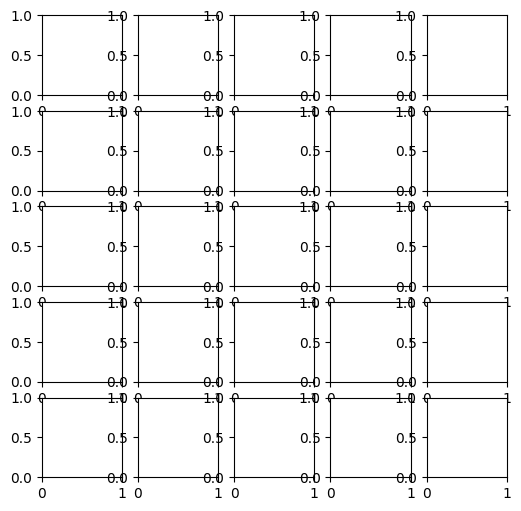

In [51]:
fig, axes = plt.subplots(5,5, figsize=(6,6))

In [52]:
count = 0

In [53]:
for i in range(5):
    for j in range(5):
        axes[i,j].imshow(generated[count,:,:,0], cmap='gray')
        axes[i,j].axis('off')
        count += 1

In [54]:
plt.show()